# Import data and libraries


In [ ]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T
from transformers import CLIPProcessor, CLIPModel
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from utils import extract_latents




In [ ]:
def unpickle(file):
    with open(file, 'rb') as fo:
        d = pickle.load(fo, encoding='bytes')
    return d

train_dict = unpickle("/content/train")
test_dict  = unpickle("/content/test")
meta_dict  = unpickle("/content/meta")


# Baseline 3-NN

In [ ]:
X_train_all = train_dict[b'data']          # (50000, 3072)
y_train_all = np.array(train_dict[b'fine_labels'])

X_test_all  = test_dict[b'data']           # (10000, 3072)
y_test_all  = np.array(test_dict[b'fine_labels'])

class_names = [c.decode('utf-8') for c in meta_dict[b'fine_label_names']]


In [ ]:
np.random.seed(0)
selected_classes = np.random.choice(range(100), size=10, replace=False)
selected_classes = sorted(selected_classes)


In [ ]:
def filter_classes(X, y, selected):
    mask = np.isin(y, selected)
    X_filt = X[mask]
    y_filt = y[mask]

    # remap labels → 0..9
    label_map = {old:i for i, old in enumerate(selected)}
    y_filt = np.array([label_map[label] for label in y_filt])

    return X_filt, y_filt


In [ ]:
X_train, y_train = filter_classes(X_train_all, y_train_all, selected_classes)
X_test, y_test   = filter_classes(X_test_all, y_test_all, selected_classes)


In [ ]:
X_train = X_train / 255.0
X_test  = X_test / 255.0


In [ ]:

knn = KNeighborsClassifier(
    n_neighbors=3,
    metric='euclidean'
)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)


In [ ]:
acc = accuracy_score(y_test, y_pred)
cm  = confusion_matrix(y_test, y_pred)

print("Accuracy:", acc)
print("Confusion matrix:\n", cm)


Accuracy: 0.353
Confusion matrix:
 [[41  9 23  0 12  3  1  6  4  1]
 [13 44 15  3 12  3  1  5  4  0]
 [12  7 47  2 10  6  3  2 11  0]
 [19 10 33 21  7  5  0  4  1  0]
 [ 8  9 22  4 40  8  3  0  3  3]
 [ 2  3 14  0 10 54  1  0  7  9]
 [ 5  5 25  0 35  3 24  1  2  0]
 [ 9 21 13  2 14  3  0 34  2  2]
 [ 8  6 15  0 21 25  5  4 15  1]
 [ 1  4 11  2 16 27  1  4  1 33]]


In [ ]:

cm = confusion_matrix(y_test, y_pred)

# Κρατάμε μόνο τα λάθη (μηδενίζουμε τη διαγώνιο)
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)

# Βρίσκουμε τα indices ταξινομημένα κατά φθίνουσα τιμή
flat_indices = np.argsort(cm_off, axis=None)[::-1]

print("\nTop Confusions:")

count = 0
for idx in flat_indices:
    i, j = np.unravel_index(idx, cm_off.shape)

    if cm_off[i, j] > 0:
        print(f"{class_names[i]} misclassified as {class_names[j]}: {cm_off[i,j]} times")
        count += 1

    if count == 5:   # δείξε μόνο τα 5 μεγαλύτερα
        break


Top Confusions:
bee misclassified as beaver: 35 times
bear misclassified as baby: 33 times
bottle misclassified as bed: 27 times
bicycle misclassified as bed: 25 times
bee misclassified as baby: 25 times


# Autoencoder

In [ ]:


np.random.seed(3)
selected_classes = sorted(np.random.choice(range(100), size=10, replace=False))

def filter_classes(X, y, selected):
    mask = np.isin(y, selected)
    X_filt = X[mask].astype(np.float32)
    y_filt = y[mask]

    label_map = {old:i for i, old in enumerate(selected)}
    y_filt = np.array([label_map[int(lbl)] for lbl in y_filt], dtype=np.int64)
    return X_filt, y_filt

X_train, y_train = filter_classes(X_train_all, y_train_all, selected_classes)
X_test,  y_test  = filter_classes(X_test_all,  y_test_all,  selected_classes)

# pixels to [0,1]
X_train = X_train / 255.0
X_test  = X_test  / 255.0

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Selected CIFAR-100 class ids:", selected_classes)


Train: (5000, 3072) Test: (1000, 3072)
Selected CIFAR-100 class ids: [np.int64(6), np.int64(15), np.int64(25), np.int64(42), np.int64(64), np.int64(67), np.int64(83), np.int64(93), np.int64(96), np.int64(98)]


In [ ]:


class FlatDataset(Dataset):
    def __init__(self, X):
        self.X = torch.from_numpy(X)  # float32 (N,3072)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        x = self.X[idx]
        return x, x

batch_size = 256
train_loader = DataLoader(FlatDataset(X_train), batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

## FCA : Baseline


In [ ]:


class AE_PyGfG(nn.Module):
    def __init__(self, input_dim=3072, latent_dim=128):
        super(AE_PyGfG, self).__init__()

        # Encoder (FC)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, latent_dim)
        )

        # Decoder (FC)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, input_dim),
            nn.Sigmoid()  # έτσι ώστε η έξοδος να είναι στο [0,1]
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out, z


In [ ]:


class FlatDataset(Dataset):
    def __init__(self, X):
        self.X = torch.from_numpy(X).float()
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        x = self.X[idx]
        return x, x   # autoencoder: input = target

batch_size = 256
train_loader = DataLoader(FlatDataset(X_train), batch_size=batch_size, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AE_PyGfG(input_dim=3072, latent_dim=128).to(device)


optimizer = Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(1, 101):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        out, _ = model(x)
        loss = loss_fn(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
    print(f"Epoch {epoch:02d} | Train loss: {total_loss/len(train_loader.dataset):.6f}")


<class '__main__.AE_PyGfG'>
Epoch 01 | Train loss: 0.062771
Epoch 02 | Train loss: 0.048711
Epoch 03 | Train loss: 0.039608
Epoch 04 | Train loss: 0.034797
Epoch 05 | Train loss: 0.032348
Epoch 06 | Train loss: 0.031569
Epoch 07 | Train loss: 0.031216
Epoch 08 | Train loss: 0.031036
Epoch 09 | Train loss: 0.030902
Epoch 10 | Train loss: 0.030789
Epoch 11 | Train loss: 0.031169
Epoch 12 | Train loss: 0.028677
Epoch 13 | Train loss: 0.026951
Epoch 14 | Train loss: 0.026270
Epoch 15 | Train loss: 0.026086
Epoch 16 | Train loss: 0.025569
Epoch 17 | Train loss: 0.025293
Epoch 18 | Train loss: 0.024587
Epoch 19 | Train loss: 0.024072
Epoch 20 | Train loss: 0.023287
Epoch 21 | Train loss: 0.022831
Epoch 22 | Train loss: 0.023211
Epoch 23 | Train loss: 0.022493
Epoch 24 | Train loss: 0.022320
Epoch 25 | Train loss: 0.022233
Epoch 26 | Train loss: 0.022152
Epoch 27 | Train loss: 0.022060
Epoch 28 | Train loss: 0.024676
Epoch 29 | Train loss: 0.022049
Epoch 30 | Train loss: 0.021242
Epoch 31 | T

In [ ]:
print(model)


AE_PyGfG(
  (encoder): Sequential(
    (0): Linear(in_features=3072, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=128, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=1024, bias=True)
    (3): ReLU()
    (4): Linear(in_features=1024, out_features=3072, bias=True)
    (5): Sigmoid()
  )
)


In [ ]:


@torch.no_grad()
def extract_latent(model, X):
    model.eval()
    Z = []
    for i in range(0, len(X), 512):
        batch = torch.from_numpy(X[i:i+512]).to(device)
        _, z = model(batch)
        Z.append(z.cpu().numpy())
    return np.vstack(Z)

Z_train = extract_latent(model, X_train)
Z_test  = extract_latent(model, X_test)

print("Latent shapes:", Z_train.shape, Z_test.shape)


Latent shapes: (5000, 128) (1000, 128)


In [ ]:

scaler = StandardScaler()
Z_train_s = scaler.fit_transform(Z_train)
Z_test_s  = scaler.transform(Z_test)

knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn.fit(Z_train_s, y_train)

y_pred = knn.predict(Z_test_s)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("3-NN accuracy (AE):", acc)
print("Confusion matrix:\n", cm)


3-NN accuracy (AE): 0.408
Confusion matrix:
 [[56 10  6 13  5  3  4  2  1  0]
 [12 45  6 14  4  3  1  5  8  2]
 [ 9 17 44 10  5  1  3  4  7  0]
 [ 9 18 12 41  8  6  1  4  1  0]
 [ 8  7 10 31 24  9  1  3  4  3]
 [ 6  1  8 11  4 52  1 17  0  0]
 [19 10  4 11  1  3 41  3  7  1]
 [ 9 12  9  6  5 21  0 31  6  1]
 [ 5  7 10  6  4  5  0  1 61  1]
 [10 13 15 19 14  3  7  3  3 13]]


## FCA : Loss optimixer change


In [ ]:
np.random.seed(3)
selected_classes = sorted(np.random.choice(range(100), size=10, replace=False))

def filter_classes(X, y, selected):
    mask = np.isin(y, selected)
    X_filt = X[mask].astype(np.float32)
    y_filt = y[mask]

    label_map = {old:i for i, old in enumerate(selected)}
    y_filt = np.array([label_map[int(lbl)] for lbl in y_filt], dtype=np.int64)
    return X_filt, y_filt

X_train, y_train = filter_classes(X_train_all, y_train_all, selected_classes)
X_test,  y_test  = filter_classes(X_test_all,  y_test_all,  selected_classes)

# pixels to [0,1]
X_train = X_train / 255.0
X_test  = X_test  / 255.0

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Selected CIFAR-100 class ids:", selected_classes)


Train: (5000, 3072) Test: (1000, 3072)
Selected CIFAR-100 class ids: [np.int64(6), np.int64(15), np.int64(25), np.int64(42), np.int64(64), np.int64(67), np.int64(83), np.int64(93), np.int64(96), np.int64(98)]


In [ ]:


class FlatDataset(Dataset):
    def __init__(self, X):
        self.X = torch.from_numpy(X)  # float32 (N,3072)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        x = self.X[idx]
        return x, x

batch_size = 256
train_loader = DataLoader(FlatDataset(X_train), batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [ ]:


class AE_PyGfG(nn.Module):
    def __init__(self, input_dim=3072, latent_dim=128):
        super(AE_PyGfG, self).__init__()

        # Encoder (FC)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, latent_dim)
        )

        # Decoder (FC)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, input_dim),
            nn.Sigmoid()  # έτσι ώστε η έξοδος να είναι στο [0,1]
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out, z


In [ ]:


class FlatDataset(Dataset):
    def __init__(self, X):
        self.X = torch.from_numpy(X).float()
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        x = self.X[idx]
        return x, x   # autoencoder: input = target

batch_size = 256
train_loader = DataLoader(FlatDataset(X_train), batch_size=batch_size, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AE_PyGfG(input_dim=3072, latent_dim=128).to(device)


optimizer = Adam(model.parameters(), lr=1e-3)
loss_fn = nn.SmoothL1Loss(beta=0.5)

for epoch in range(1, 101):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        out, _ = model(x)
        loss = loss_fn(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
    print(f"Epoch {epoch:02d} | Train loss: {total_loss/len(train_loader.dataset):.6f}")


Epoch 01 | Train loss: 0.063174
Epoch 02 | Train loss: 0.046132
Epoch 03 | Train loss: 0.038922
Epoch 04 | Train loss: 0.033650
Epoch 05 | Train loss: 0.031602
Epoch 06 | Train loss: 0.031655
Epoch 07 | Train loss: 0.031043
Epoch 08 | Train loss: 0.031066
Epoch 09 | Train loss: 0.030967
Epoch 10 | Train loss: 0.030360
Epoch 11 | Train loss: 0.028715
Epoch 12 | Train loss: 0.028330
Epoch 13 | Train loss: 0.026991
Epoch 14 | Train loss: 0.026310
Epoch 15 | Train loss: 0.025872
Epoch 16 | Train loss: 0.025702
Epoch 17 | Train loss: 0.024923
Epoch 18 | Train loss: 0.024444
Epoch 19 | Train loss: 0.024398
Epoch 20 | Train loss: 0.023482
Epoch 21 | Train loss: 0.022864
Epoch 22 | Train loss: 0.022512
Epoch 23 | Train loss: 0.022457
Epoch 24 | Train loss: 0.022388
Epoch 25 | Train loss: 0.022248
Epoch 26 | Train loss: 0.022147
Epoch 27 | Train loss: 0.021965
Epoch 28 | Train loss: 0.021875
Epoch 29 | Train loss: 0.021256
Epoch 30 | Train loss: 0.021165
Epoch 31 | Train loss: 0.020659
Epoch 32

In [ ]:

@torch.no_grad()
def extract_latent(model, X):
    model.eval()
    Z = []
    for i in range(0, len(X), 512):
        batch = torch.from_numpy(X[i:i+512]).to(device)
        _, z = model(batch)
        Z.append(z.cpu().numpy())
    return np.vstack(Z)

Z_train = extract_latent(model, X_train)
Z_test  = extract_latent(model, X_test)

print("Latent shapes:", Z_train.shape, Z_test.shape)


Latent shapes: (5000, 128) (1000, 128)


In [ ]:

scaler = StandardScaler()
Z_train_s = scaler.fit_transform(Z_train)
Z_test_s  = scaler.transform(Z_test)

knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn.fit(Z_train_s, y_train)

y_pred = knn.predict(Z_test_s)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("3-NN accuracy (AE):", acc)
print("Confusion matrix:\n", cm)


3-NN accuracy (AE): 0.402
Confusion matrix:
 [[56 10  6 13  6  2  1  1  5  0]
 [ 9 43  5 12  9  4  1  4 13  0]
 [12 10 42 10  5  4  3  5  8  1]
 [ 9 18  7 47  8  5  0  3  3  0]
 [ 8 10  9 25 32  6  0  4  4  2]
 [ 1  6  8  9 11 45  1 18  1  0]
 [18  9  6 10  1  3 41  2 10  0]
 [12 10  6  8  9 20  0 26  8  1]
 [10  6  8 13  4  1  0  1 56  1]
 [17 15  8 18 12  3  6  4  3 14]]


## FCA : Architecture change

In [ ]:

np.random.seed(3)
selected_classes = sorted(np.random.choice(range(100), size=10, replace=False))

def filter_classes(X, y, selected):
    mask = np.isin(y, selected)
    X_filt = X[mask].astype(np.float32)
    y_filt = y[mask]

    label_map = {old:i for i, old in enumerate(selected)}
    y_filt = np.array([label_map[int(lbl)] for lbl in y_filt], dtype=np.int64)
    return X_filt, y_filt

X_train, y_train = filter_classes(X_train_all, y_train_all, selected_classes)
X_test,  y_test  = filter_classes(X_test_all,  y_test_all,  selected_classes)

# pixels to [0,1]
X_train = X_train / 255.0
X_test  = X_test  / 255.0

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Selected CIFAR-100 class ids:", selected_classes)


Train: (5000, 3072) Test: (1000, 3072)
Selected CIFAR-100 class ids: [np.int64(6), np.int64(15), np.int64(25), np.int64(42), np.int64(64), np.int64(67), np.int64(83), np.int64(93), np.int64(96), np.int64(98)]


In [ ]:


class FlatDataset(Dataset):
    def __init__(self, X):
        self.X = torch.from_numpy(X)  # float32 (N,3072)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        x = self.X[idx]
        return x, x

batch_size = 256
train_loader = DataLoader(FlatDataset(X_train), batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [ ]:


class AE_PyGfG(nn.Module):
    def __init__(self, input_dim=3072, latent_dim=128):
        super(AE_PyGfG, self).__init__()

        # Encoder (FC)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 2048),
    nn.ReLU(),
    nn.Linear(2048, 1024),
    nn.ReLU(),
    nn.Linear(1024, 256),
    nn.ReLU(),
    nn.Linear(256, latent_dim)
        )

        # Decoder (FC)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
    nn.ReLU(),
    nn.Linear(256, 1024),
    nn.ReLU(),
    nn.Linear(1024, 2048),
    nn.ReLU(),
    nn.Linear(2048, input_dim),
    nn.Sigmoid()# έτσι ώστε η έξοδος να είναι στο [0,1]
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out, z


In [ ]:


class FlatDataset(Dataset):
    def __init__(self, X):
        self.X = torch.from_numpy(X).float()
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        x = self.X[idx]
        return x, x   # autoencoder: input = target

batch_size = 256
train_loader = DataLoader(FlatDataset(X_train), batch_size=batch_size, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AE_PyGfG(input_dim=3072, latent_dim=128).to(device)


optimizer = Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(1, 101):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        out, _ = model(x)
        loss = loss_fn(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
    print(f"Epoch {epoch:02d} | Train loss: {total_loss/len(train_loader.dataset):.6f}")


Epoch 01 | Train loss: 0.063979
Epoch 02 | Train loss: 0.049228
Epoch 03 | Train loss: 0.043904
Epoch 04 | Train loss: 0.041871
Epoch 05 | Train loss: 0.039471
Epoch 06 | Train loss: 0.036744
Epoch 07 | Train loss: 0.036072
Epoch 08 | Train loss: 0.035465
Epoch 09 | Train loss: 0.035137
Epoch 10 | Train loss: 0.035040
Epoch 11 | Train loss: 0.036488
Epoch 12 | Train loss: 0.033175
Epoch 13 | Train loss: 0.031553
Epoch 14 | Train loss: 0.031113
Epoch 15 | Train loss: 0.030982
Epoch 16 | Train loss: 0.030895
Epoch 17 | Train loss: 0.030779
Epoch 18 | Train loss: 0.030694
Epoch 19 | Train loss: 0.030754
Epoch 20 | Train loss: 0.030572
Epoch 21 | Train loss: 0.030483
Epoch 22 | Train loss: 0.030853
Epoch 23 | Train loss: 0.030622
Epoch 24 | Train loss: 0.030306
Epoch 25 | Train loss: 0.030208
Epoch 26 | Train loss: 0.030358
Epoch 27 | Train loss: 0.030759
Epoch 28 | Train loss: 0.029199
Epoch 29 | Train loss: 0.027593
Epoch 30 | Train loss: 0.026688
Epoch 31 | Train loss: 0.025928
Epoch 32

In [ ]:
print(model)


AE_PyGfG(
  (encoder): Sequential(
    (0): Linear(in_features=3072, out_features=2048, bias=True)
    (1): ReLU()
    (2): Linear(in_features=2048, out_features=1024, bias=True)
    (3): ReLU()
    (4): Linear(in_features=1024, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=128, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=1024, bias=True)
    (3): ReLU()
    (4): Linear(in_features=1024, out_features=2048, bias=True)
    (5): ReLU()
    (6): Linear(in_features=2048, out_features=3072, bias=True)
    (7): Sigmoid()
  )
)


In [ ]:


@torch.no_grad()
def extract_latent(model, X):
    model.eval()
    Z = []
    for i in range(0, len(X), 512):
        batch = torch.from_numpy(X[i:i+512]).to(device)
        _, z = model(batch)
        Z.append(z.cpu().numpy())
    return np.vstack(Z)

Z_train = extract_latent(model, X_train)
Z_test  = extract_latent(model, X_test)

print("Latent shapes:", Z_train.shape, Z_test.shape)


Latent shapes: (5000, 128) (1000, 128)


In [ ]:

scaler = StandardScaler()
Z_train_s = scaler.fit_transform(Z_train)
Z_test_s  = scaler.transform(Z_test)

knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn.fit(Z_train_s, y_train)

y_pred = knn.predict(Z_test_s)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("3-NN accuracy (AE):", acc)
print("Confusion matrix:\n", cm)


3-NN accuracy (AE): 0.359
Confusion matrix:
 [[52 18  4 10  4  2  7  2  1  0]
 [12 37 10 15  8  1  0  6 10  1]
 [ 5 18 43 10  4  2  4  4  7  3]
 [11 16 12 40 10  3  1  3  3  1]
 [14 11  7 30 25  4  0  2  5  2]
 [12  8  8  9  6 37  0 20  0  0]
 [13  7 10  7  4  2 43  2  9  3]
 [10 21  6  8 10 19  1 21  3  1]
 [ 8 14  6  9  6  4  2  4 46  1]
 [18 14 12 16 14  2  5  2  2 15]]


## CAE : Baseline

In [ ]:

def unpickle(file):
    with open(file, 'rb') as fo:
        d = pickle.load(fo, encoding='bytes')
    return d

train_dict = unpickle("/content/train")
test_dict  = unpickle("/content/test")
meta_dict  = unpickle("/content/meta")

Selected classes: [np.int64(2), np.int64(16), np.int64(26), np.int64(54), np.int64(55), np.int64(73), np.int64(75), np.int64(86), np.int64(93), np.int64(95)]
Selected names: ['baby', 'can', 'crab', 'orchid', 'otter', 'shark', 'skunk', 'telephone', 'turtle', 'whale']
Train subset: (5000, 3072) Test subset: (1000, 3072)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [1/100]  Train Loss: 0.069130  Test Loss: 0.037905
Epoch [5/100]  Train Loss: 0.021705  Test Loss: 0.021643
Epoch [10/100]  Train Loss: 0.013501  Test Loss: 0.012898
Epoch [15/100]  Train Loss: 0.010471  Test Loss: 0.010532
Epoch [20/100]  Train Loss: 0.009205  Test Loss: 0.009256
Epoch [25/100]  Train Loss: 0.008451  Test Loss: 0.008638
Epoch [30/100]  Train Loss: 0.008002  Test Loss: 0.008177
Epoch [35/100]  Train Loss: 0.007676  Test Loss: 0.007832
Epoch [40/100]  Train Loss: 0.007550  Test Loss: 0.007534
Epoch [45/100]  Train Loss: 0.007192  Test Loss: 0.007245
Epoch [50/100]  Train Loss: 0.006939  Test Loss: 0.007239
Epoch [55/100]  Train Loss: 0.006778  Test Loss: 0.006842
Epoch [60/100]  Train Loss: 0.006576  Test Loss: 0.006762
Epoch [65/100]  Train Loss: 0.006354  Test Loss: 0.006944
Epoch [70/100]  Train Loss: 0.005910  Test Loss: 0.005968
Epoch [75/100]  Train Loss: 0.005700  Test Loss: 0.005856
Epoch [80/100]  Train Loss: 0.005363  Test Loss: 0.005475
Epoch [85/100]  

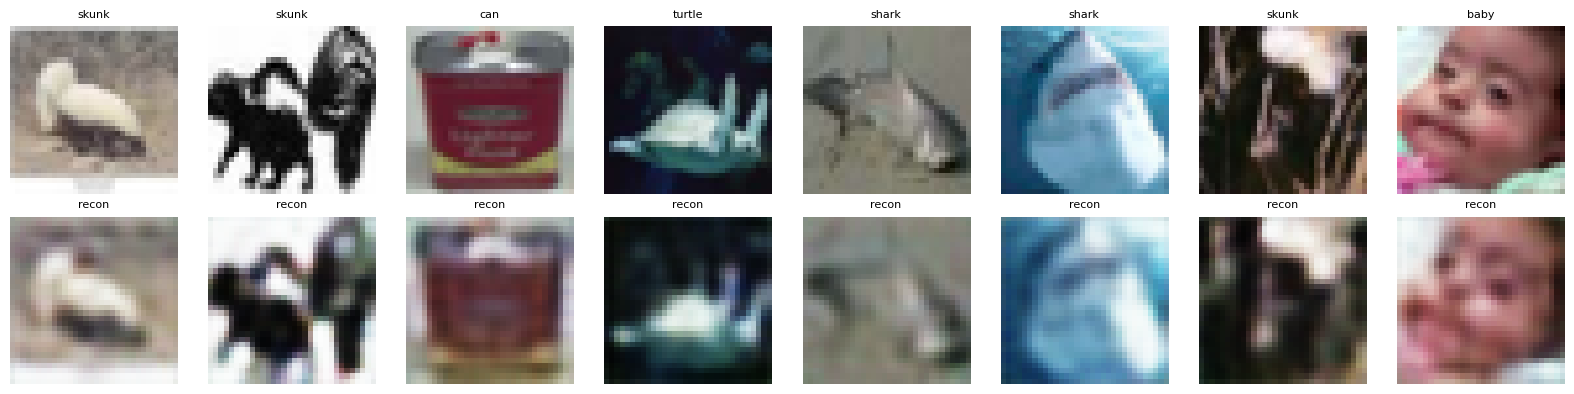

In [ ]:
X_train_all = train_dict[b'data']          # (50000, 3072) uint8
y_train_all = np.array(train_dict[b'fine_labels'])

X_test_all  = test_dict[b'data']           # (10000, 3072) uint8
y_test_all  = np.array(test_dict[b'fine_labels'])

class_names = [c.decode('utf-8') for c in meta_dict[b'fine_label_names']]

np.random.seed(0)
selected_classes = np.random.choice(range(100), size=10, replace=False)
selected_classes = sorted(selected_classes)

print("Selected classes:", selected_classes)
print("Selected names:", [class_names[i] for i in selected_classes])

# -----------------------
# 2) Filter σε 10 κλάσεις (προαιρετικό αλλά το ζήτησες)
# -----------------------
train_mask = np.isin(y_train_all, selected_classes)
test_mask  = np.isin(y_test_all, selected_classes)

X_train = X_train_all[train_mask]
y_train = y_train_all[train_mask]
X_test  = X_test_all[test_mask]
y_test  = y_test_all[test_mask]

print("Train subset:", X_train.shape, "Test subset:", X_test.shape)


class CIFAR100PickleDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = X  # (N, 3072) uint8
        self.y = y  # optional

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]  # (3072,)
        # CIFAR: 1024 R, 1024 G, 1024 B
        x = x.reshape(3, 32, 32).astype(np.float32) / 255.0  # CHW, [0,1]
        x = torch.from_numpy(x)
        if self.y is None:
            return x
        return x, int(self.y[idx])

train_ds = CIFAR100PickleDataset(X_train, y_train)
test_ds  = CIFAR100PickleDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)


class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 32x32
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                             # 16x16

            nn.Conv2d(32, 16, kernel_size=3, padding=1), # 16x16
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                             # 8x8

            nn.Conv2d(16, 8, kernel_size=3, padding=1),  # 8x8 bottleneck
            nn.ReLU(inplace=True),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16, kernel_size=3, stride=2, padding=1, output_padding=1),  # 16x16
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(16, 32, kernel_size=3, stride=2, padding=1, output_padding=1), # 32x32
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 3, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvAutoencoder().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


def train_one_epoch():
    model.train()
    running = 0.0
    for images, _ in train_loader:
        images = images.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()

        running += loss.item() * images.size(0)
    return running / len(train_loader.dataset)

@torch.no_grad()
def eval_loss():
    model.eval()
    running = 0.0
    for images, _ in test_loader:
        images = images.to(device, non_blocking=True)
        outputs = model(images)
        loss = criterion(outputs, images)
        running += loss.item() * images.size(0)
    return running / len(test_loader.dataset)

epochs = 100
for epoch in range(1, epochs + 1):
    tr = train_one_epoch()
    te = eval_loss()
    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch [{epoch}/{epochs}]  Train Loss: {tr:.6f}  Test Loss: {te:.6f}")



@torch.no_grad()
def show_reconstructions(n=8):
    model.eval()
    images, labels = next(iter(test_loader))
    images = images[:n].to(device)
    recons = model(images).cpu()

    images = images.cpu()

    plt.figure(figsize=(2*n, 4))
    # originals
    for i in range(n):
        ax = plt.subplot(2, n, i + 1)
        img = images[i].permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.set_title(class_names[labels[i].item()], fontsize=8)
        ax.axis("off")

    # reconstructions
    for i in range(n):
        ax = plt.subplot(2, n, n + i + 1)
        img = recons[i].permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.set_title("recon", fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_reconstructions(n=8)

In [ ]:

def knn_3nn_eval():
    Ztr, ytr = extract_latents(train_loader)
    Zte, yte = extract_latents(test_loader)

    scaler = StandardScaler()
    Ztr = scaler.fit_transform(Ztr)
    Zte = scaler.transform(Zte)

    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(Ztr, ytr)
    pred = knn.predict(Zte)

    acc = accuracy_score(yte, pred)
    cm = confusion_matrix(yte, pred, labels=selected_classes)

    print("\n--- 3-NN on latent space ---")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion matrix shape:", cm.shape)

    return acc, cm  #

In [ ]:
print(model)

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(32, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): Sigmoid()
  )
)


In [ ]:
acc, cm = knn_3nn_eval()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



--- 3-NN on latent space ---
Accuracy: 0.4110
Confusion matrix shape: (10, 10)


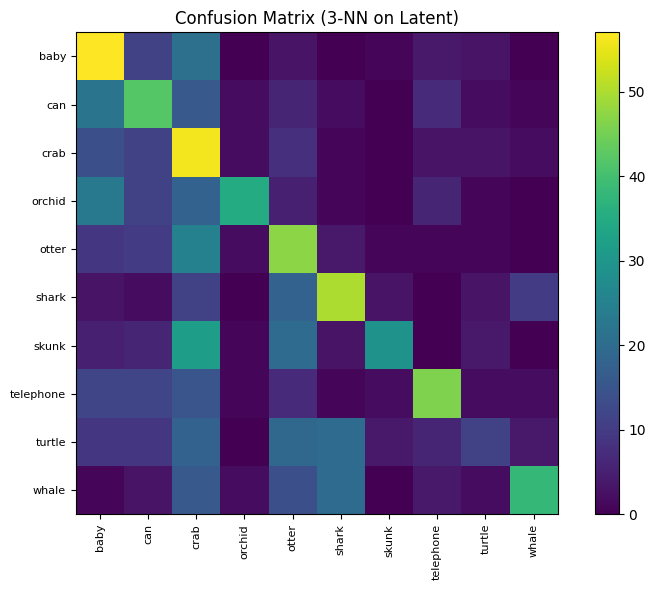

In [ ]:
def plot_cm(cm):
    plt.figure(figsize=(8,6))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix (3-NN on Latent)")
    plt.colorbar()
    tick_labels = [class_names[c] for c in selected_classes]
    plt.xticks(range(10), tick_labels, rotation=90, fontsize=8)
    plt.yticks(range(10), tick_labels, fontsize=8)
    plt.tight_layout()
    plt.show()

plot_cm(cm)

## CAE : Loss optimizer change

Selected classes: [np.int64(2), np.int64(16), np.int64(26), np.int64(54), np.int64(55), np.int64(73), np.int64(75), np.int64(86), np.int64(93), np.int64(95)]
Selected names: ['baby', 'can', 'crab', 'orchid', 'otter', 'shark', 'skunk', 'telephone', 'turtle', 'whale']
Train subset: (5000, 3072) Test subset: (1000, 3072)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [1/100]  Train Loss: 0.033508  Test Loss: 0.021993
Epoch [5/100]  Train Loss: 0.010679  Test Loss: 0.010898
Epoch [10/100]  Train Loss: 0.006720  Test Loss: 0.006535
Epoch [15/100]  Train Loss: 0.005329  Test Loss: 0.005351
Epoch [20/100]  Train Loss: 0.004847  Test Loss: 0.004937
Epoch [25/100]  Train Loss: 0.004447  Test Loss: 0.004447
Epoch [30/100]  Train Loss: 0.004165  Test Loss: 0.004280
Epoch [35/100]  Train Loss: 0.003912  Test Loss: 0.004050
Epoch [40/100]  Train Loss: 0.003794  Test Loss: 0.004142
Epoch [45/100]  Train Loss: 0.003585  Test Loss: 0.003662
Epoch [50/100]  Train Loss: 0.003489  Test Loss: 0.003521
Epoch [55/100]  Train Loss: 0.003407  Test Loss: 0.003442
Epoch [60/100]  Train Loss: 0.003324  Test Loss: 0.003410
Epoch [65/100]  Train Loss: 0.003321  Test Loss: 0.003328
Epoch [70/100]  Train Loss: 0.003181  Test Loss: 0.003252
Epoch [75/100]  Train Loss: 0.003112  Test Loss: 0.003258
Epoch [80/100]  Train Loss: 0.003052  Test Loss: 0.003122
Epoch [85/100]  

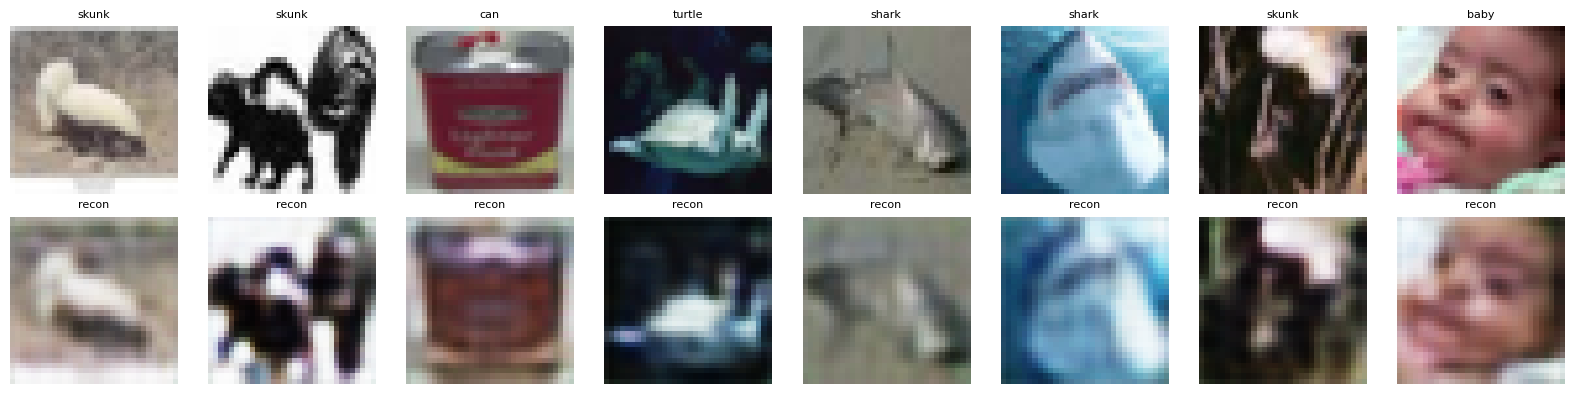

In [ ]:

X_train_all = train_dict[b'data']          # (50000, 3072) uint8
y_train_all = np.array(train_dict[b'fine_labels'])

X_test_all  = test_dict[b'data']           # (10000, 3072) uint8
y_test_all  = np.array(test_dict[b'fine_labels'])

class_names = [c.decode('utf-8') for c in meta_dict[b'fine_label_names']]

np.random.seed(0)
selected_classes = np.random.choice(range(100), size=10, replace=False)
selected_classes = sorted(selected_classes)

print("Selected classes:", selected_classes)
print("Selected names:", [class_names[i] for i in selected_classes])

train_mask = np.isin(y_train_all, selected_classes)
test_mask  = np.isin(y_test_all, selected_classes)

X_train = X_train_all[train_mask]
y_train = y_train_all[train_mask]
X_test  = X_test_all[test_mask]
y_test  = y_test_all[test_mask]

print("Train subset:", X_train.shape, "Test subset:", X_test.shape)


class CIFAR100PickleDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = X  # (N, 3072) uint8
        self.y = y  # optional

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]  # (3072,)
        # CIFAR: 1024 R, 1024 G, 1024 B
        x = x.reshape(3, 32, 32).astype(np.float32) / 255.0  # CHW, [0,1]
        x = torch.from_numpy(x)
        if self.y is None:
            return x
        return x, int(self.y[idx])

train_ds = CIFAR100PickleDataset(X_train, y_train)
test_ds  = CIFAR100PickleDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)


class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 32x32
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                             # 16x16

            nn.Conv2d(32, 16, kernel_size=3, padding=1), # 16x16
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                             # 8x8

            nn.Conv2d(16, 8, kernel_size=3, padding=1),  # 8x8 bottleneck
            nn.ReLU(inplace=True),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16, kernel_size=3, stride=2, padding=1, output_padding=1),  # 16x16
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(16, 32, kernel_size=3, stride=2, padding=1, output_padding=1), # 32x32
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 3, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvAutoencoder().to(device)

#MSE -> SmoothL1 (Huber)
criterion = nn.SmoothL1Loss()

optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch():
    model.train()
    running = 0.0
    for images, _ in train_loader:
        images = images.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()

        running += loss.item() * images.size(0)
    return running / len(train_loader.dataset)

@torch.no_grad()
def eval_loss():
    model.eval()
    running = 0.0
    for images, _ in test_loader:
        images = images.to(device, non_blocking=True)
        outputs = model(images)
        loss = criterion(outputs, images)
        running += loss.item() * images.size(0)
    return running / len(test_loader.dataset)

epochs = 100
for epoch in range(1, epochs + 1):
    tr = train_one_epoch()
    te = eval_loss()
    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch [{epoch}/{epochs}]  Train Loss: {tr:.6f}  Test Loss: {te:.6f}")


@torch.no_grad()
def show_reconstructions(n=8):
    model.eval()
    images, labels = next(iter(test_loader))
    images = images[:n].to(device)
    recons = model(images).cpu()

    images = images.cpu()

    plt.figure(figsize=(2*n, 4))
    # originals
    for i in range(n):
        ax = plt.subplot(2, n, i + 1)
        img = images[i].permute(1, 2, 0).numpy()
        ax.imshow(img)

        ax.set_title(class_names[labels[i].item()], fontsize=8)
        ax.axis("off")

    # reconstructions
    for i in range(n):
        ax = plt.subplot(2, n, n + i + 1)
        img = recons[i].permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.set_title("recon", fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_reconstructions(n=8)

In [ ]:
@torch.no_grad()
def extract_latents(loader):
    model.eval()
    Z_list, y_list = [], []
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        z = model.encoder(images)                # (B, 8, 8, 8)
        z = z.view(z.size(0), -1).cpu().numpy()  # (B, 512)
        Z_list.append(z)
        y_list.append(labels.numpy())
    Z = np.concatenate(Z_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    return Z, y

def knn_3nn_eval():
    Ztr, ytr = extract_latents(train_loader)
    Zte, yte = extract_latents(test_loader)

    scaler = StandardScaler()
    Ztr = scaler.fit_transform(Ztr)
    Zte = scaler.transform(Zte)

    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(Ztr, ytr)
    pred = knn.predict(Zte)

    acc = accuracy_score(yte, pred)

    # labels: οι 10 πραγματικοί CIFAR-100 fine label ids που διάλεξες
    cm = confusion_matrix(yte, pred, labels=selected_classes)

    print("\n--- 3-NN on latent space ---")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion matrix shape:", cm.shape)

    return acc, cm

In [ ]:
acc, cm = knn_3nn_eval()


--- 3-NN on latent space ---
Accuracy: 0.4220
Confusion matrix shape: (10, 10)


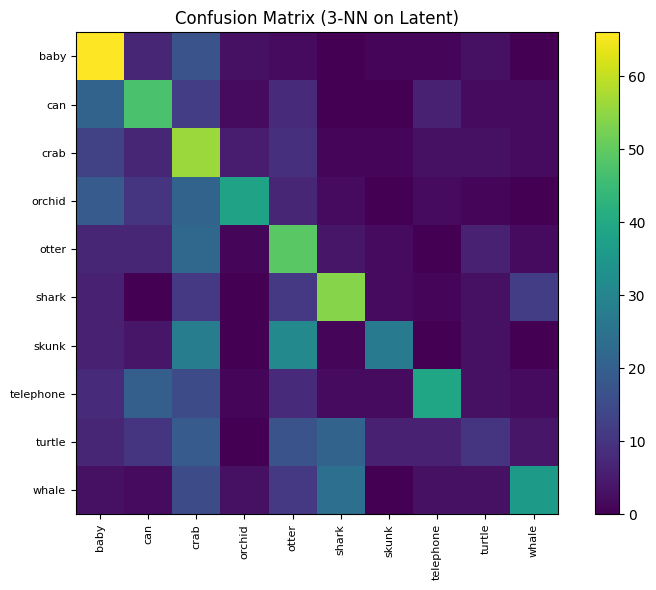

In [ ]:
def plot_cm(cm):
    plt.figure(figsize=(8,6))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix (3-NN on Latent)")
    plt.colorbar()
    tick_labels = [class_names[c] for c in selected_classes]
    plt.xticks(range(10), tick_labels, rotation=90, fontsize=8)
    plt.yticks(range(10), tick_labels, fontsize=8)
    plt.tight_layout()
    plt.show()

plot_cm(cm)

## CAE : Different Architcture 

Selected classes: [np.int64(2), np.int64(16), np.int64(26), np.int64(54), np.int64(55), np.int64(73), np.int64(75), np.int64(86), np.int64(93), np.int64(95)]
Selected names: ['baby', 'can', 'crab', 'orchid', 'otter', 'shark', 'skunk', 'telephone', 'turtle', 'whale']
Train subset: (5000, 3072) Test subset: (1000, 3072)
Epoch [1/100]  Train Loss: 0.066295  Test Loss: 0.042455
Epoch [5/100]  Train Loss: 0.018644  Test Loss: 0.021879
Epoch [10/100]  Train Loss: 0.010450  Test Loss: 0.009982
Epoch [15/100]  Train Loss: 0.008590  Test Loss: 0.008628
Epoch [20/100]  Train Loss: 0.007779  Test Loss: 0.007408
Epoch [25/100]  Train Loss: 0.006719  Test Loss: 0.006800
Epoch [30/100]  Train Loss: 0.006290  Test Loss: 0.006803
Epoch [35/100]  Train Loss: 0.006225  Test Loss: 0.005988
Epoch [40/100]  Train Loss: 0.005587  Test Loss: 0.005916
Epoch [45/100]  Train Loss: 0.005304  Test Loss: 0.006048
Epoch [50/100]  Train Loss: 0.005704  Test Loss: 0.005502
Epoch [55/100]  Train Loss: 0.005011  Test L

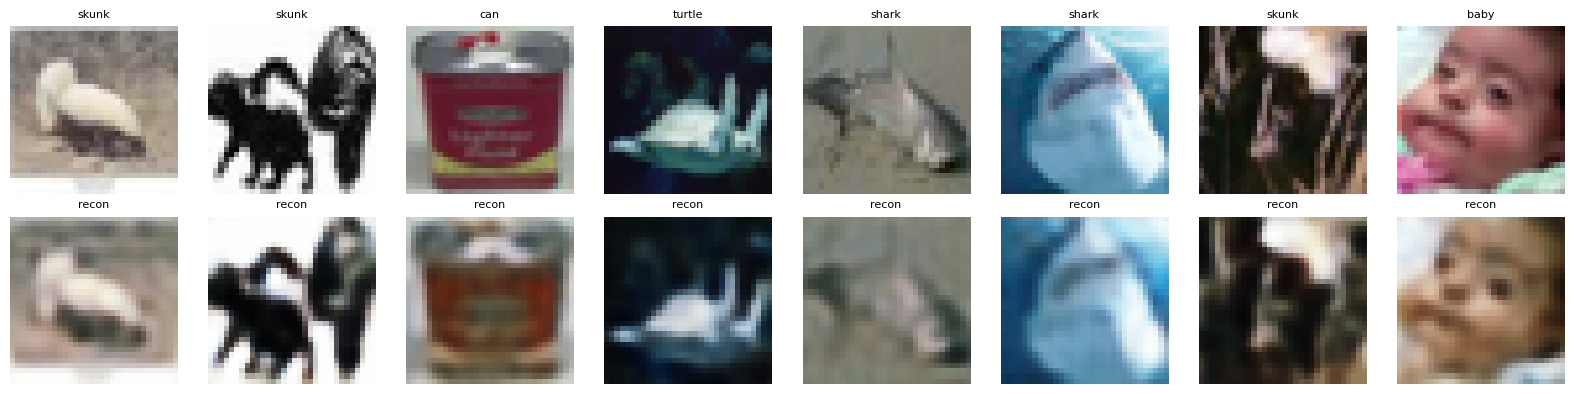

In [ ]:

X_train_all = train_dict[b'data']          # (50000, 3072) uint8
y_train_all = np.array(train_dict[b'fine_labels'])

X_test_all  = test_dict[b'data']           # (10000, 3072) uint8
y_test_all  = np.array(test_dict[b'fine_labels'])

class_names = [c.decode('utf-8') for c in meta_dict[b'fine_label_names']]

np.random.seed(0)
selected_classes = np.random.choice(range(100), size=10, replace=False)
selected_classes = sorted(selected_classes)

print("Selected classes:", selected_classes)
print("Selected names:", [class_names[i] for i in selected_classes])

train_mask = np.isin(y_train_all, selected_classes)
test_mask  = np.isin(y_test_all, selected_classes)

X_train = X_train_all[train_mask]
y_train = y_train_all[train_mask]
X_test  = X_test_all[test_mask]
y_test  = y_test_all[test_mask]

print("Train subset:", X_train.shape, "Test subset:", X_test.shape)


class CIFAR100PickleDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = X  # (N, 3072) uint8
        self.y = y  # optional

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]  # (3072,)
        # CIFAR: 1024 R, 1024 G, 1024 B
        x = x.reshape(3, 32, 32).astype(np.float32) / 255.0  # CHW, [0,1]
        x = torch.from_numpy(x)
        if self.y is None:
            return x
        return x, int(self.y[idx])

train_ds = CIFAR100PickleDataset(X_train, y_train)
test_ds  = CIFAR100PickleDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 8x8

            nn.Conv2d(64, 8, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 64, kernel_size=3, stride=2, padding=1, output_padding=1),  # 16x16
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), # 32x32
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 3, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvAutoencoder().to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=1e-3)


def train_one_epoch():
    model.train()
    running = 0.0
    for images, _ in train_loader:
        images = images.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()

        running += loss.item() * images.size(0)
    return running / len(train_loader.dataset)

@torch.no_grad()
def eval_loss():
    model.eval()
    running = 0.0
    for images, _ in test_loader:
        images = images.to(device, non_blocking=True)
        outputs = model(images)
        loss = criterion(outputs, images)
        running += loss.item() * images.size(0)
    return running / len(test_loader.dataset)



epochs = 100
for epoch in range(1, epochs + 1):
    tr = train_one_epoch()
    te = eval_loss()
    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch [{epoch}/{epochs}]  Train Loss: {tr:.6f}  Test Loss: {te:.6f}")


@torch.no_grad()
def show_reconstructions(n=8):
    model.eval()
    images, labels = next(iter(test_loader))
    images = images[:n].to(device)
    recons = model(images).cpu()

    images = images.cpu()

    plt.figure(figsize=(2*n, 4))
    # originals
    for i in range(n):
        ax = plt.subplot(2, n, i + 1)
        img = images[i].permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.set_title(class_names[labels[i].item()], fontsize=8)
        ax.axis("off")

    # reconstructions
    for i in range(n):
        ax = plt.subplot(2, n, n + i + 1)
        img = recons[i].permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.set_title("recon", fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_reconstructions(n=8)

In [ ]:
@torch.no_grad()
def extract_latents(loader):
    model.eval()
    Z_list, y_list = [], []
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        z = model.encoder(images)                # (B, 8, 8, 8)
        z = z.view(z.size(0), -1).cpu().numpy()  # (B, 512)
        Z_list.append(z)
        y_list.append(labels.numpy())
    Z = np.concatenate(Z_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    return Z, y

def knn_3nn_eval():
    Ztr, ytr = extract_latents(train_loader)
    Zte, yte = extract_latents(test_loader)

    scaler = StandardScaler()
    Ztr = scaler.fit_transform(Ztr)
    Zte = scaler.transform(Zte)

    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(Ztr, ytr)
    pred = knn.predict(Zte)

    acc = accuracy_score(yte, pred)

    cm = confusion_matrix(yte, pred, labels=selected_classes)

    print("\n--- 3-NN on latent space ---")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion matrix shape:", cm.shape)

    return acc, cm

In [ ]:
print(model)

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(64, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(8, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): 

In [ ]:
acc, cm = knn_3nn_eval()


--- 3-NN on latent space ---
Accuracy: 0.3850
Confusion matrix shape: (10, 10)


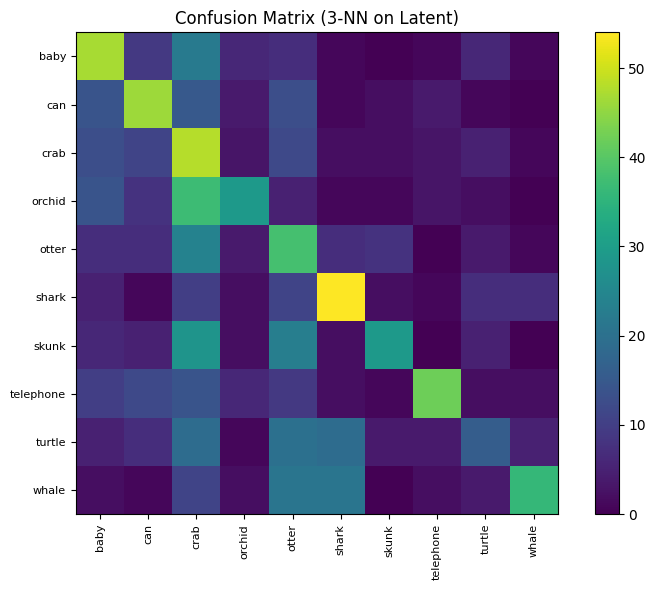

In [ ]:
def plot_cm(cm):
    plt.figure(figsize=(8,6))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix (3-NN on Latent)")
    plt.colorbar()
    tick_labels = [class_names[c] for c in selected_classes]
    plt.xticks(range(10), tick_labels, rotation=90, fontsize=8)
    plt.yticks(range(10), tick_labels, fontsize=8)
    plt.tight_layout()
    plt.show()

plot_cm(cm)

## CAE : Extra test to check if the raise in acc is due to latent or CAE

Selected classes: [np.int64(2), np.int64(16), np.int64(26), np.int64(54), np.int64(55), np.int64(73), np.int64(75), np.int64(86), np.int64(93), np.int64(95)]
Selected names: ['baby', 'can', 'crab', 'orchid', 'otter', 'shark', 'skunk', 'telephone', 'turtle', 'whale']
Train subset: (5000, 3072) Test subset: (1000, 3072)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [1/100]  Train Loss: 0.072799  Test Loss: 0.051782
Epoch [5/100]  Train Loss: 0.022982  Test Loss: 0.022954
Epoch [10/100]  Train Loss: 0.018538  Test Loss: 0.017763
Epoch [15/100]  Train Loss: 0.012893  Test Loss: 0.013583
Epoch [20/100]  Train Loss: 0.012072  Test Loss: 0.012284
Epoch [25/100]  Train Loss: 0.011549  Test Loss: 0.011845
Epoch [30/100]  Train Loss: 0.011082  Test Loss: 0.011238
Epoch [35/100]  Train Loss: 0.010527  Test Loss: 0.010732
Epoch [40/100]  Train Loss: 0.010044  Test Loss: 0.010279
Epoch [45/100]  Train Loss: 0.009607  Test Loss: 0.009917
Epoch [50/100]  Train Loss: 0.009299  Test Loss: 0.009471
Epoch [55/100]  Train Loss: 0.009063  Test Loss: 0.009276
Epoch [60/100]  Train Loss: 0.008839  Test Loss: 0.009052
Epoch [65/100]  Train Loss: 0.008719  Test Loss: 0.008961
Epoch [70/100]  Train Loss: 0.008596  Test Loss: 0.008838
Epoch [75/100]  Train Loss: 0.008474  Test Loss: 0.008624
Epoch [80/100]  Train Loss: 0.008364  Test Loss: 0.008494
Epoch [85/100]  

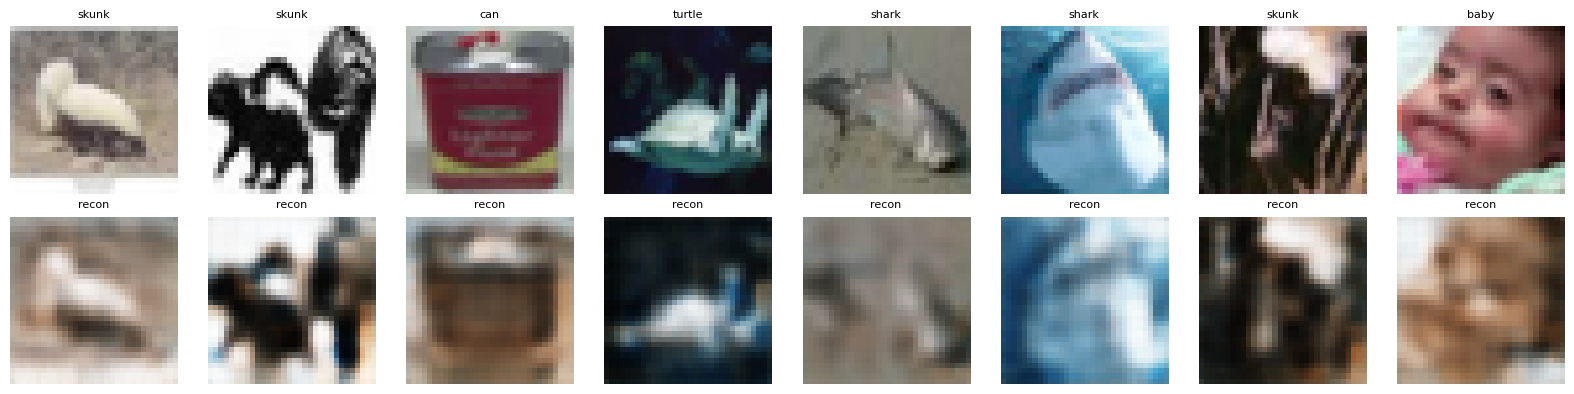

In [ ]:
X_train_all = train_dict[b'data']          # (50000, 3072) uint8
y_train_all = np.array(train_dict[b'fine_labels'])

X_test_all  = test_dict[b'data']           # (10000, 3072) uint8
y_test_all  = np.array(test_dict[b'fine_labels'])

class_names = [c.decode('utf-8') for c in meta_dict[b'fine_label_names']]

np.random.seed(0)
selected_classes = np.random.choice(range(100), size=10, replace=False)
selected_classes = sorted(selected_classes)

print("Selected classes:", selected_classes)
print("Selected names:", [class_names[i] for i in selected_classes])


train_mask = np.isin(y_train_all, selected_classes)
test_mask  = np.isin(y_test_all, selected_classes)

X_train = X_train_all[train_mask]
y_train = y_train_all[train_mask]
X_test  = X_test_all[test_mask]
y_test  = y_test_all[test_mask]

print("Train subset:", X_train.shape, "Test subset:", X_test.shape)


class CIFAR100PickleDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = X  # (N, 3072) uint8
        self.y = y  # optional

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]  # (3072,)
        # CIFAR: 1024 R, 1024 G, 1024 B
        x = x.reshape(3, 32, 32).astype(np.float32) / 255.0  # CHW, [0,1]
        x = torch.from_numpy(x)
        if self.y is None:
            return x
        return x, int(self.y[idx])

train_ds = CIFAR100PickleDataset(X_train, y_train)
test_ds  = CIFAR100PickleDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)


class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 32x32
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                             # 16x16

            nn.Conv2d(32, 16, kernel_size=3, padding=1), # 16x16
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                             # 8x8

            nn.Conv2d(16, 2, kernel_size=3, padding=1),  # 8x8 bottleneck => 128 dims
            nn.ReLU(inplace=True),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(2, 16, kernel_size=3, stride=2, padding=1, output_padding=1),  # 16x16
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(16, 32, kernel_size=3, stride=2, padding=1, output_padding=1), # 32x32
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 3, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)     # (B, 2, 8, 8)
        out = self.decoder(z)
        return out

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvAutoencoder().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


def train_one_epoch():
    model.train()
    running = 0.0
    for images, _ in train_loader:
        images = images.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()

        running += loss.item() * images.size(0)
    return running / len(train_loader.dataset)

@torch.no_grad()
def eval_loss():
    model.eval()
    running = 0.0
    for images, _ in test_loader:
        images = images.to(device, non_blocking=True)
        outputs = model(images)
        loss = criterion(outputs, images)
        running += loss.item() * images.size(0)
    return running / len(test_loader.dataset)

epochs = 100
for epoch in range(1, epochs + 1):
    tr = train_one_epoch()
    te = eval_loss()
    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch [{epoch}/{epochs}]  Train Loss: {tr:.6f}  Test Loss: {te:.6f}")


@torch.no_grad()
def show_reconstructions(n=8):
    model.eval()
    images, labels = next(iter(test_loader))
    images = images[:n].to(device)
    recons = model(images).cpu()

    images = images.cpu()

    plt.figure(figsize=(2*n, 4))
    # originals
    for i in range(n):
        ax = plt.subplot(2, n, i + 1)
        img = images[i].permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.set_title(class_names[labels[i].item()], fontsize=8)
        ax.axis("off")

    # reconstructions
    for i in range(n):
        ax = plt.subplot(2, n, n + i + 1)
        img = recons[i].permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.set_title("recon", fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_reconstructions(n=8)

In [ ]:
def knn_3nn_eval():
    Ztr, ytr = extract_latents(train_loader)
    Zte, yte = extract_latents(test_loader)

    scaler = StandardScaler()
    Ztr = scaler.fit_transform(Ztr)
    Zte = scaler.transform(Zte)

    knn = KNeighborsClassifier(n_neighbors=3, metric="euclidean")
    knn.fit(Ztr, ytr)
    pred = knn.predict(Zte)

    acc = accuracy_score(yte, pred)

    cm = confusion_matrix(yte, pred, labels=selected_classes)

    print("\n--- 3-NN on latent space ---")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion matrix shape:", cm.shape)

    return acc, cm

acc, cm = knn_3nn_eval()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



--- 3-NN on latent space ---
Accuracy: 0.3840
Confusion matrix shape: (10, 10)


In [ ]:
print(model)

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(16, 2, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(2, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(32, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): Sigmoid()
  )
)


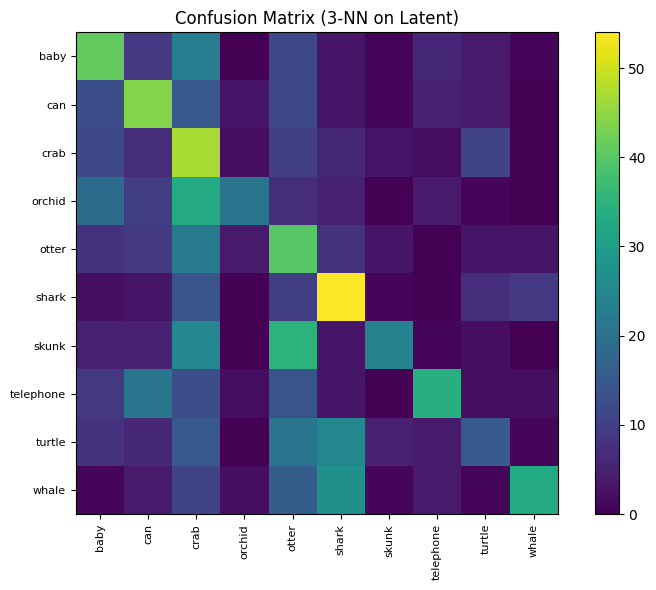

In [ ]:
def plot_cm(cm):
    plt.figure(figsize=(8,6))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix (3-NN on Latent)")
    plt.colorbar()
    tick_labels = [class_names[c] for c in selected_classes]
    plt.xticks(range(10), tick_labels, rotation=90, fontsize=8)
    plt.yticks(range(10), tick_labels, fontsize=8)
    plt.tight_layout()
    plt.show()

plot_cm(cm)

# Embeddings

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_all = train_dict[b'data']          # (50000, 3072) uint8
y_train_all = np.array(train_dict[b'fine_labels'])
X_test_all  = test_dict[b'data']           # (10000, 3072) uint8
y_test_all  = np.array(test_dict[b'fine_labels'])
class_names = [c.decode('utf-8') for c in meta_dict[b'fine_label_names']]


np.random.seed(0)
selected_classes = sorted(np.random.choice(range(100), size=10, replace=False))
print("Selected classes:", selected_classes)
print("Selected names:", [class_names[i] for i in selected_classes])

def filter_classes(X, y, selected):
    mask = np.isin(y, selected)
    X_f = X[mask]
    y_f = y[mask]

    label_map = {old:i for i, old in enumerate(selected)}  # CIFAR id -> 0..9
    y_f = np.array([label_map[int(lbl)] for lbl in y_f], dtype=np.int64)

    return X_f, y_f

X_train_u8, y_train = filter_classes(X_train_all, y_train_all, selected_classes)
X_test_u8,  y_test  = filter_classes(X_test_all,  y_test_all,  selected_classes)

print("Train subset:", X_train_u8.shape, "Test subset:", X_test_u8.shape)
print("Train labels unique:", np.unique(y_train))
print("Test labels unique:", np.unique(y_test))


Selected classes: [np.int64(2), np.int64(16), np.int64(26), np.int64(54), np.int64(55), np.int64(73), np.int64(75), np.int64(86), np.int64(93), np.int64(95)]
Selected names: ['baby', 'can', 'crab', 'orchid', 'otter', 'shark', 'skunk', 'telephone', 'turtle', 'whale']
Train subset: (5000, 3072) Test subset: (1000, 3072)
Train labels unique: [0 1 2 3 4 5 6 7 8 9]
Test labels unique: [0 1 2 3 4 5 6 7 8 9]


## CLIP Embeddings (512-d) + 3NN Euclidean

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP embedding dim: 512

--- CLIP (512d) | 3-NN (k=3, Euclidean) ---
Accuracy: 0.8610


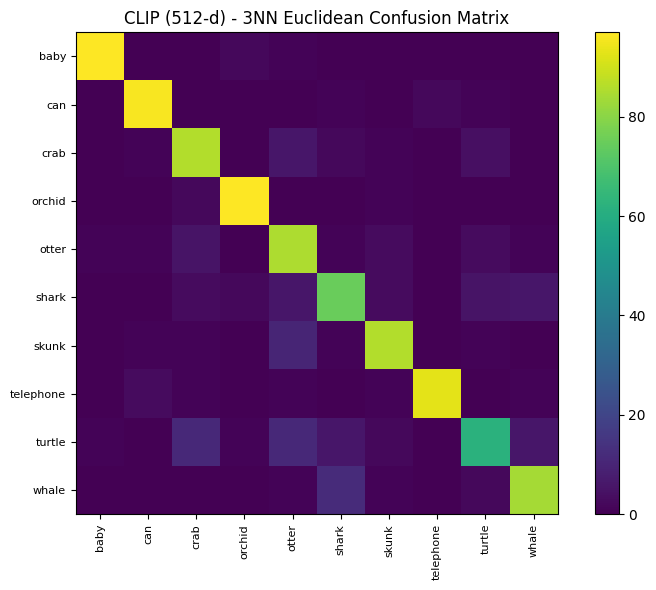

In [ ]:
def plot_cm(cm, title):
    plt.figure(figsize=(8,6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    tick_labels = [class_names[c] for c in selected_classes]  # names of the 10 chosen classes
    plt.xticks(range(10), tick_labels, rotation=90, fontsize=8)
    plt.yticks(range(10), tick_labels, fontsize=8)

    plt.tight_layout()
    plt.show()

class CIFARClipDataset(Dataset):
    def __init__(self, X_u8, y):
        self.X = X_u8
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        img = self.X[idx].reshape(3, 32, 32).astype(np.uint8)
        img = np.transpose(img, (1, 2, 0))  # HWC uint8
        return img, int(self.y[idx])

train_loader_clip = DataLoader(CIFARClipDataset(X_train_u8, y_train), batch_size=128, shuffle=False)
test_loader_clip  = DataLoader(CIFARClipDataset(X_test_u8,  y_test),  batch_size=128, shuffle=False)

clip_name = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(clip_name).to(device)
clip_processor = CLIPProcessor.from_pretrained(clip_name)
clip_model.eval()

@torch.no_grad()
def extract_clip_embeddings(loader):
    Z_list, y_list = [], []
    for images, labels in loader:
        inputs = clip_processor(images=list(images), return_tensors="pt")
        pixel_values = inputs["pixel_values"].to(device)

        vision_out = clip_model.vision_model(pixel_values=pixel_values)
        pooled = vision_out.pooler_output
        feats = clip_model.visual_projection(pooled)  # (B, 512)

        # L2 normalize (preprocessing)
        feats = feats / feats.norm(dim=1, keepdim=True)

        Z_list.append(feats.cpu().numpy())
        y_list.append(labels.numpy())

    return np.concatenate(Z_list, axis=0), np.concatenate(y_list, axis=0)

Ztr_clip, ytr_clip = extract_clip_embeddings(train_loader_clip)
Zte_clip, yte_clip = extract_clip_embeddings(test_loader_clip)
print("CLIP embedding dim:", Ztr_clip.shape[1])  # 512

knn_clip = KNeighborsClassifier(n_neighbors=3, metric="euclidean")
knn_clip.fit(Ztr_clip, ytr_clip)
pred_clip = knn_clip.predict(Zte_clip)

acc_clip = accuracy_score(yte_clip, pred_clip)
cm_clip  = confusion_matrix(yte_clip, pred_clip, labels=list(range(10)))

print("\n--- CLIP (512d) | 3-NN (k=3, Euclidean) ---")
print(f"Accuracy: {acc_clip:.4f}")
plot_cm(cm_clip, "CLIP (512-d) - 3NN Euclidean Confusion Matrix")


## ResNet-18 Embeddings (512-d) + 3NN Euclidean

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 154MB/s]


ResNet embedding dim: 512

--- ResNet-18 (512d) | 3-NN (k=3, Euclidean) ---
Accuracy: 0.8370


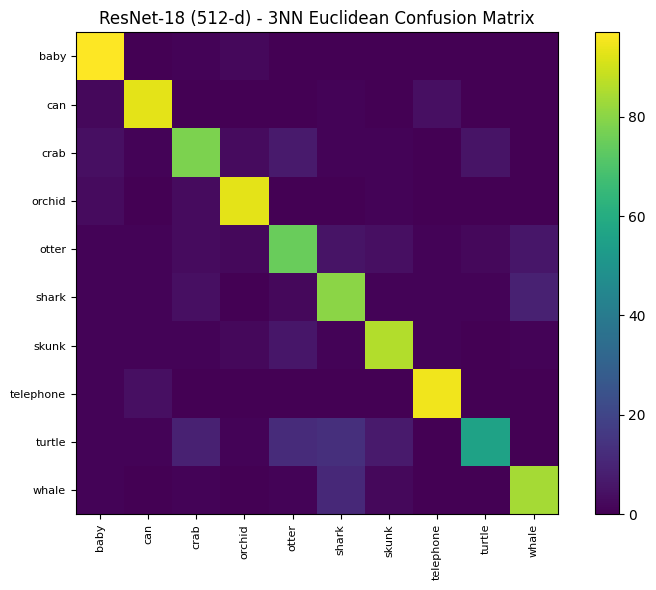

In [ ]:
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet.fc = nn.Identity()  # 512-d features
resnet = resnet.to(device)
resnet.eval()

resnet_transform = T.Compose([
    T.Resize(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

class CIFARResNetDataset(Dataset):
    def __init__(self, X_u8, y):
        self.X = X_u8
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        img = self.X[idx].reshape(3, 32, 32).astype(np.uint8)
        img = np.transpose(img, (1, 2, 0))  # HWC
        img = Image.fromarray(img)
        img = resnet_transform(img)
        return img, int(self.y[idx])

train_loader_res = DataLoader(CIFARResNetDataset(X_train_u8, y_train), batch_size=128, shuffle=False)
test_loader_res  = DataLoader(CIFARResNetDataset(X_test_u8,  y_test),  batch_size=128, shuffle=False)

@torch.no_grad()
def extract_resnet_embeddings(loader):
    Z_list, y_list = [], []
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        feats = resnet(images)  # (B,512)

        # L2 normalize (preprocessing)
        feats = feats / feats.norm(dim=1, keepdim=True)

        Z_list.append(feats.cpu().numpy())
        y_list.append(labels.numpy())

    return np.concatenate(Z_list, axis=0), np.concatenate(y_list, axis=0)

Ztr_res, ytr_res = extract_resnet_embeddings(train_loader_res)
Zte_res, yte_res = extract_resnet_embeddings(test_loader_res)
print("ResNet embedding dim:", Ztr_res.shape[1])  # 512

knn_res = KNeighborsClassifier(n_neighbors=3, metric="euclidean")
knn_res.fit(Ztr_res, ytr_res)
pred_res = knn_res.predict(Zte_res)

acc_res = accuracy_score(yte_res, pred_res)
cm_res  = confusion_matrix(yte_res, pred_res, labels=list(range(10)))

print("\n--- ResNet-18 (512d) | 3-NN (k=3, Euclidean) ---")
print(f"Accuracy: {acc_res:.4f}")
plot_cm(cm_res, "ResNet-18 (512-d) - 3NN Euclidean Confusion Matrix")

## PCA/t-SNE

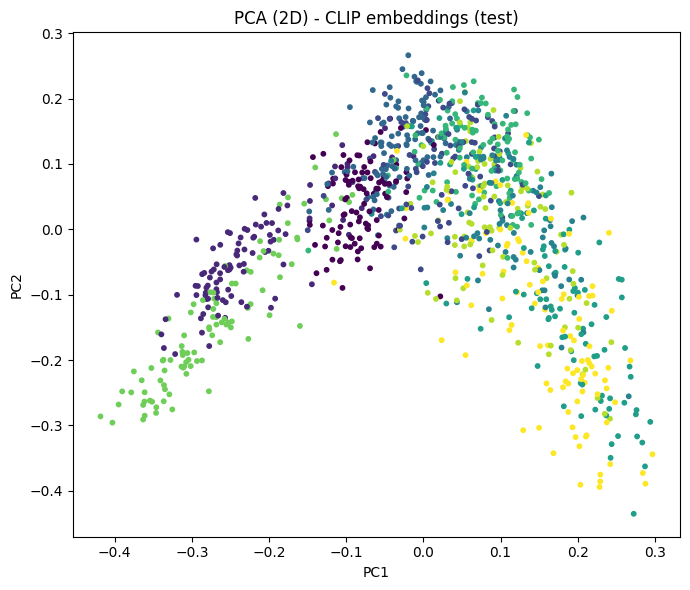

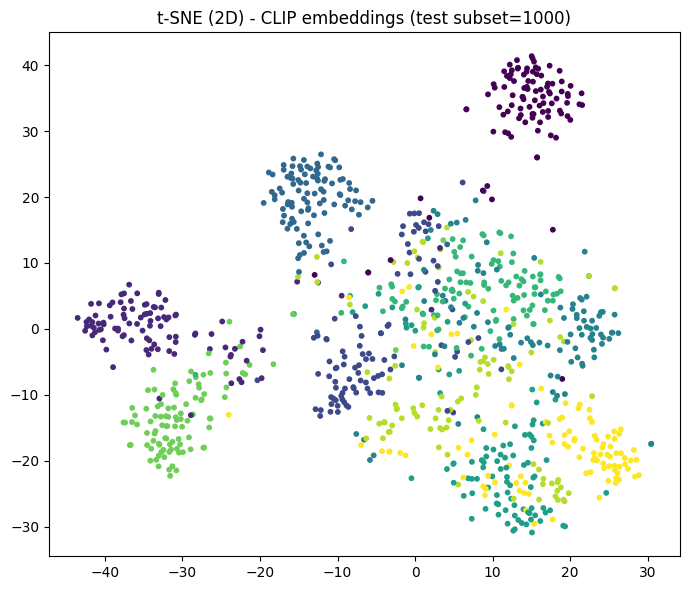

In [ ]:
pca = PCA(n_components=2, random_state=0)
pca.fit(Ztr_clip)
Z_clip_pca = pca.transform(Zte_clip)

plt.figure(figsize=(7,6))
plt.scatter(Z_clip_pca[:,0], Z_clip_pca[:,1], c=yte_clip, s=10)
plt.title("PCA (2D) - CLIP embeddings (test)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# t-SNE on subset for speed
n_points = min(2000, len(Zte_clip))
idx = np.random.RandomState(0).choice(len(Zte_clip), n_points, replace=False)

tsne = TSNE(n_components=2, perplexity=30, random_state=0, init="pca", learning_rate="auto")
Z_clip_tsne = tsne.fit_transform(Zte_clip[idx])

plt.figure(figsize=(7,6))
plt.scatter(Z_clip_tsne[:,0], Z_clip_tsne[:,1], c=yte_clip[idx], s=10)
plt.title(f"t-SNE (2D) - CLIP embeddings (test subset={n_points})")
plt.tight_layout()
plt.show()

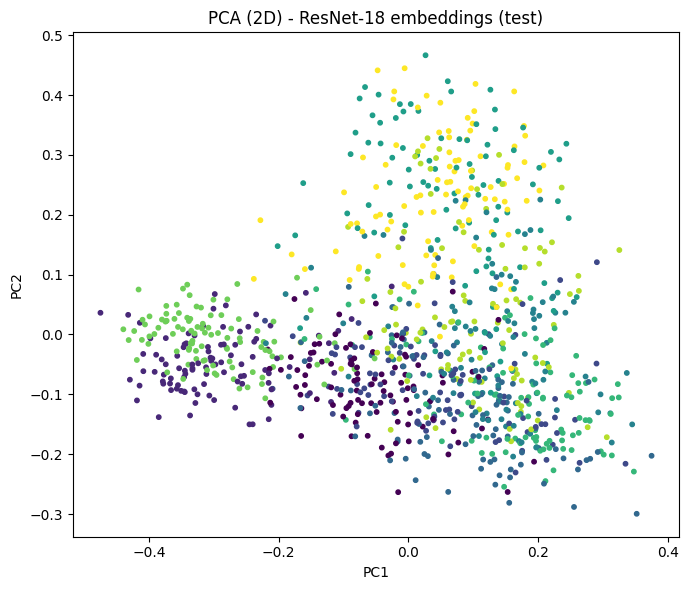

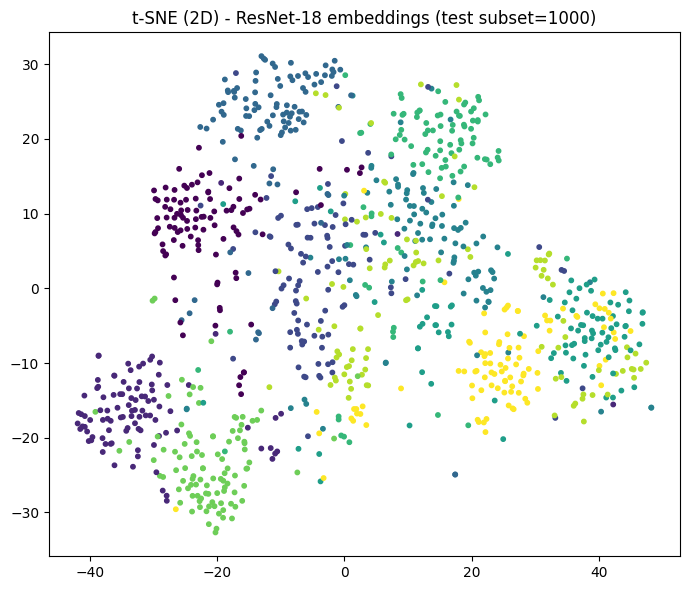

In [ ]:


pca = PCA(n_components=2, random_state=0)
pca.fit(Ztr_res)
Z_res_pca = pca.transform(Zte_res)

plt.figure(figsize=(7,6))
plt.scatter(Z_res_pca[:,0], Z_res_pca[:,1], c=yte_res, s=10)
plt.title("PCA (2D) - ResNet-18 embeddings (test)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


n_points = min(2000, len(Zte_res))
idx = np.random.RandomState(0).choice(len(Zte_res), n_points, replace=False)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=0,
    init="pca",
    learning_rate="auto"
)
Z_res_tsne = tsne.fit_transform(Zte_res[idx])

plt.figure(figsize=(7,6))
plt.scatter(Z_res_tsne[:,0], Z_res_tsne[:,1], c=yte_res[idx], s=10)
plt.title(f"t-SNE (2D) - ResNet-18 embeddings (test subset={n_points})")
plt.tight_layout()
plt.show()